In [39]:
from pathlib import Path
import tensorflow_model_analysis as tfma

# project paths
PROJECT_ROOT = Path("/mnt/c/Users/said_/Documents/COMP-315-Team-Project")
EVAL_DIR = PROJECT_ROOT / "tfx_pipeline_output_v2" / "Evaluator" / "evaluation" / "8"

print("evaluation folder:", EVAL_DIR)
print("files found:")
for path in sorted(EVAL_DIR.iterdir()):
    print("-", path.name)

evaluation folder: /mnt/c/Users/said_/Documents/COMP-315-Team-Project/tfx_pipeline_output_v2/Evaluator/evaluation/8
files found:
- attributions-00000-of-00001.tfrecord
- eval_config.json
- metrics-00000-of-00001.tfrecord
- plots-00000-of-00001.tfrecord
- validations.tfrecord


In [40]:
eval_result = tfma.load_eval_result(str(EVAL_DIR))
print("tfma result loaded successfully")

tfma result loaded successfully


In [41]:
tfma.view.render_slicing_metrics(eval_result)

SlicingMetricsViewer(config={'weightedExamplesColumn': 'example_count'}, data=[{'slice': 'Overall', 'metrics':…

### Interpretation: Overall model performance

The overall TFMA results show that the model performs reasonably well on the evaluation data, with solid classification accuracy and AUC. This means the model is generally able to distinguish between the income classes better than random guessing. However, overall performance alone is not enough to evaluate fairness, because a strong overall score can still hide weaker performance for specific demographic groups. Therefore, we need to look at the performance metrics broken down by the sensitive feature (in this case,sex) to get a clearer picture of how the model performs across different slices of the data.

In [42]:
tfma.view.render_slicing_metrics(eval_result, slicing_column='sex')

SlicingMetricsViewer(config={'weightedExamplesColumn': 'example_count'}, data=[{'slice': 'sex:Male', 'metrics'…

### Interpretation: Performance by sex

The sex slices show a noticeable performance gap between groups. In these results, the female slice performs better than the male slice in both AUC and binary accuracy. This suggests that the model is not equally reliable across the two sex categories. A possible explanation is that the training data may contain imbalances or different feature patterns across groups, which can lead the model to generalize better for one slice than another. This kind of disparity is a common fairness concern, as it indicates that the model may be less effective at predicting outcomes for one group, which can lead to unequal treatment in real-world applications.

In [43]:
tfma.view.render_slicing_metrics(eval_result, slicing_column='race')

SlicingMetricsViewer(config={'weightedExamplesColumn': 'example_count'}, data=[{'slice': 'race:White', 'metric…

### Interpretation: Performance by race

The race slices also show uneven model behavior. Some race groups achieve stronger AUC and binary accuracy than others, while at least one group performs noticeably worse. This is important because it shows that the model’s quality is not consistent across all demographic slices. If this system were used in practice, these gaps would raise fairness concerns and would justify additional work on data quality, representation, and model tuning.

In [44]:
import os
os.environ["PROTOCOL_BUFFERS_PYTHON_IMPLEMENTATION"] = "python"
print("protobuf workaround set")

protobuf workaround set


In [45]:
from pathlib import Path
import pandas as pd
import tensorflow as tf

PROJECT_ROOT = Path("/mnt/c/Users/said_/Documents/COMP-315-Team-Project")
DATA_PATH = PROJECT_ROOT / "data" / "Dataset1_adult" / "source" / "adult.csv"

# find the exported savedmodel automatically
saved_model_pb = next((PROJECT_ROOT / "tfx_pipeline_output_v2" / "Trainer" / "model" / "7").rglob("saved_model.pb"))
MODEL_DIR = saved_model_pb.parent

loaded_model = tf.saved_model.load(str(MODEL_DIR))
serve_fn = loaded_model.signatures["serving_default"]

print("model dir:", MODEL_DIR)
print("data path:", DATA_PATH)

model dir: /mnt/c/Users/said_/Documents/COMP-315-Team-Project/tfx_pipeline_output_v2/Trainer/model/7/Format-Serving
data path: /mnt/c/Users/said_/Documents/COMP-315-Team-Project/data/Dataset1_adult/source/adult.csv


In [46]:
import tensorflow_transform as tft

# finds latest transform graph automatically
transform_root = PROJECT_ROOT / "tfx_pipeline_output_v2" / "Transform" / "transform_graph"
latest_transform_dir = max(
    [p for p in transform_root.iterdir() if p.is_dir()],
    key=lambda p: int(p.name)
)

tf_transform_output = tft.TFTransformOutput(str(latest_transform_dir))

# gets exact raw feature spec used by pipeline
raw_feature_spec = tf_transform_output.raw_feature_spec().copy()

# keeps target out of model inference examples
raw_feature_spec.pop("target", None)

# uses a small sample so wit stays fast
df = pd.read_csv(DATA_PATH).head(50).copy()

def row_to_example(row):
    ex = tf.train.Example()

    for feature_name, feature_spec in raw_feature_spec.items():
        if feature_name not in row:
            continue

        value = row[feature_name]

        if pd.isna(value):
            continue

        # uses exact dtype expected by saved model
        if feature_spec.dtype == tf.int64:
            ex.features.feature[feature_name].int64_list.value.append(int(value))

        elif feature_spec.dtype == tf.float32:
            ex.features.feature[feature_name].float_list.value.append(float(value))

        else:
            ex.features.feature[feature_name].bytes_list.value.append(
                str(value).encode("utf-8")
            )

    return ex

examples = [row_to_example(row) for _, row in df.iterrows()]

print("transform dir:", latest_transform_dir)
print("examples loaded:", len(examples))
print("raw feature keys:", list(raw_feature_spec.keys()))

transform dir: /mnt/c/Users/said_/Documents/COMP-315-Team-Project/tfx_pipeline_output_v2/Transform/transform_graph/6
examples loaded: 50
raw feature keys: ['age', 'capital-gain', 'capital-loss', 'education', 'education-num', 'fnlwgt', 'hours-per-week', 'marital-status', 'native-country', 'occupation', 'race', 'relationship', 'sex', 'workclass']


In [47]:
def custom_predict_fn(examples_to_infer):
    serialized = tf.constant([ex.SerializeToString() for ex in examples_to_infer])
    preds = serve_fn(examples=serialized)["outputs"].numpy().reshape(-1)

    # wit expects class probs for binary classification
    return [[1.0 - float(p), float(p)] for p in preds]

# sanity check :)
test_preds = custom_predict_fn(examples[:3])
print(test_preds)

[[0.6412726044654846, 0.3587273955345154], [0.550542801618576, 0.44945719838142395], [0.960616122931242, 0.03938387706875801]]


In [48]:
sample_df = df.head(5).copy()
sample_examples = [row_to_example(row) for _, row in sample_df.iterrows()]
sample_preds = custom_predict_fn(sample_examples)

sample_df["p_>50K"] = [p[1] for p in sample_preds]
sample_df[["age", "sex", "race", "hours-per-week", "education-num", "p_>50K"]]

,age,sex,race,hours-per-week,education-num,p_>50K
0,39,Male,White,40,13,0.358727
1,50,Male,White,13,13,0.449457
2,38,Male,White,40,9,0.039384
3,53,Male,Black,40,7,0.181513
4,28,Female,Black,40,13,0.810763


### Interpretation: Baseline predictions

This table shows the model’s predicted probability of earning more than 50K for a small set of original examples from the dataset. The `p_>50K` column gives a baseline prediction before any manual changes are made. These values help establish a reference point so that the effect of later counterfactual edits can be compared clearly.

In [49]:
base = df.iloc[0].copy()

sex_values = list(df["sex"].dropna().astype(str).str.strip().unique())
alt_sex = [v for v in sex_values if v != str(base["sex"]).strip()][0]

cf_sex = base.copy()
cf_sex["sex"] = alt_sex

cf_hours = base.copy()
cf_hours["hours-per-week"] = 60

cf_education = base.copy()
cf_education["education-num"] = 16

compare_df = pd.DataFrame(
    [base, cf_sex, cf_hours, cf_education],
    index=["original", "sex_changed", "hours_60", "education_16"]
)

compare_examples = [row_to_example(row) for _, row in compare_df.iterrows()]
compare_preds = custom_predict_fn(compare_examples)

compare_df["p_>50K"] = [p[1] for p in compare_preds]
compare_df[["sex", "race", "hours-per-week", "education-num", "p_>50K"]]

,sex,race,hours-per-week,education-num,p_>50K
original,Male,White,40,13,0.358727
sex_changed,Female,White,40,13,0.235742
hours_60,Male,White,60,13,0.436353
education_16,Male,White,40,16,0.555895


### Interpretation: Counterfactual experiments

This counterfactual table compares the original example with three controlled edits where only one feature was changed at a time. The three experiments were changing `sex`, increasing `hours-per-week` to 60, and increasing `education-num` to 16. Changing `sex` lowered the model’s predicted probability of earning more than 50K, while increasing working hours and education changed the prediction upward. These experiments suggest that the model is sensitive to both work-related and demographic inputs. The effect of `sex` is the most concerning because it may reflect bias or imbalance in the training data rather than purely job-related information.

In [50]:
import numpy as np
import pandas as pd

analysis_df = df.copy()

analysis_examples = [row_to_example(row) for _, row in analysis_df.iterrows()]
analysis_preds = custom_predict_fn(analysis_examples)

analysis_df["p_>50K"] = [p[1] for p in analysis_preds]
analysis_df["label"] = (
    analysis_df["target"].astype(str).str.strip().eq(">50K").astype(int)
)

def compute_binary_metrics(y_true, y_prob, threshold):
    y_true = np.array(y_true).astype(int)
    y_pred = (np.array(y_prob) >= threshold).astype(int)

    tp = int(((y_true == 1) & (y_pred == 1)).sum())
    tn = int(((y_true == 0) & (y_pred == 0)).sum())
    fp = int(((y_true == 0) & (y_pred == 1)).sum())
    fn = int(((y_true == 1) & (y_pred == 0)).sum())

    total = max(len(y_true), 1)

    return {
        "accuracy": (tp + tn) / total,
        "tpr": tp / max(tp + fn, 1),
        "fpr": fp / max(fp + tn, 1),
        "positive_rate": y_pred.mean(),
    }

thresholds = np.arange(0.10, 0.95, 0.05)

sex_groups = sorted(analysis_df["sex"].astype(str).str.strip().unique())
rows = []

for thr in thresholds:
    row = {"threshold": round(float(thr), 2)}

    for group in sex_groups:
        group_df = analysis_df[
            analysis_df["sex"].astype(str).str.strip() == group
        ]
        metrics = compute_binary_metrics(
            group_df["label"],
            group_df["p_>50K"],
            thr
        )

        row[f"{group}_accuracy"] = metrics["accuracy"]
        row[f"{group}_fpr"] = metrics["fpr"]
        row[f"{group}_tpr"] = metrics["tpr"]

    if len(sex_groups) == 2:
        g1, g2 = sex_groups[0], sex_groups[1]
        row["accuracy_gap"] = abs(
            row[f"{g1}_accuracy"] - row[f"{g2}_accuracy"]
        )
        row["fpr_gap"] = abs(
            row[f"{g1}_fpr"] - row[f"{g2}_fpr"]
        )

    rows.append(row)

sex_threshold_df = pd.DataFrame(rows)
sex_threshold_df

,threshold,Female_accuracy,Female_fpr,Female_tpr,Male_accuracy,Male_fpr,Male_tpr,accuracy_gap,fpr_gap
0,0.10,0.727273,0.333333,1.0,0.538462,0.620690,1.0,0.188811,0.287356
1,0.15,0.727273,0.222222,0.5,0.641026,0.482759,1.0,0.086247,0.260536
2,0.20,0.727273,0.222222,0.5,0.666667,0.448276,1.0,0.060606,0.226054
3,0.25,0.727273,0.222222,0.5,0.666667,0.448276,1.0,0.060606,0.226054
4,0.30,0.727273,0.222222,0.5,0.692308,0.379310,0.9,0.034965,0.157088
5,0.35,0.727273,0.222222,0.5,0.692308,0.344828,0.8,0.034965,0.122605
6,0.40,0.727273,0.222222,0.5,0.717949,0.275862,0.7,0.009324,0.053640
7,0.45,0.727273,0.222222,0.5,0.794872,0.172414,0.7,0.067599,0.049808
8,0.50,0.727273,0.222222,0.5,0.743590,0.172414,0.5,0.016317,0.049808
9,0.55,0.727273,0.222222,0.5,0.743590,0.137931,0.4,0.016317,0.084291


### Interpretation: Threshold analysis table

This table shows how the model’s performance changes across multiple decision thresholds for each sex group. The results make it easier to see whether one group consistently performs better than the other and whether the fairness gap changes as the cutoff increases. This supports the fairness analysis by showing that model behavior depends not only on the slice itself, but also on the threshold used for classification.

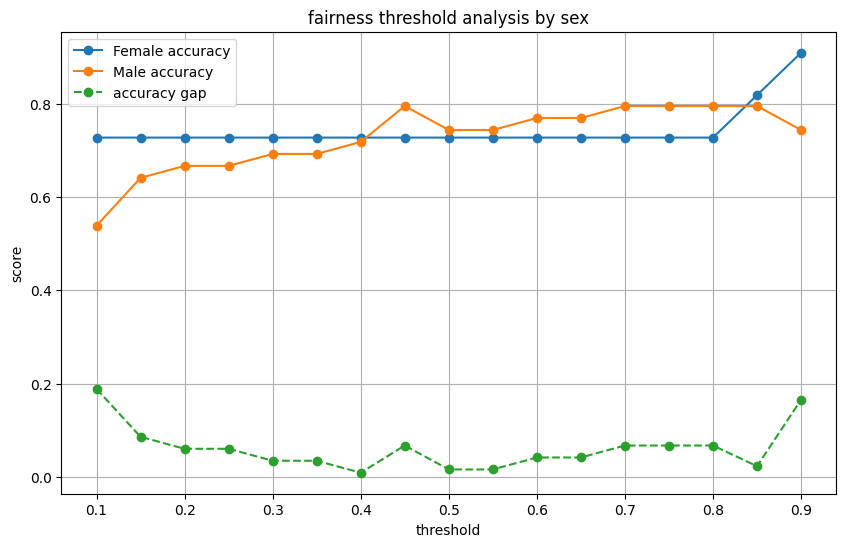

In [51]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

for group in sex_groups:
    plt.plot(
        sex_threshold_df["threshold"],
        sex_threshold_df[f"{group}_accuracy"],
        marker="o",
        label=f"{group} accuracy"
    )

plt.plot(
    sex_threshold_df["threshold"],
    sex_threshold_df["accuracy_gap"],
    marker="o",
    linestyle="--",
    label="accuracy gap"
)

plt.xlabel("threshold")
plt.ylabel("score")
plt.title("fairness threshold analysis by sex")
plt.legend()
plt.grid(True)
plt.show()

### Interpretation: Fairness threshold analysis

This threshold analysis shows how model performance changes for each sex group as the decision threshold changes. The lines do not stay perfectly aligned, which means the model behaves differently for different groups depending on where the threshold is set. The dashed accuracy-gap line shows that fairness concerns can become more or less visible at different thresholds. This is important because fairness should not be judged at only one cutoff value.